In [54]:
class CollisionEnvironment:
    """
    静态碰撞环境类
    
    这个类定义了一个包含多个多边形障碍物的静态环境。
    提供轨迹与障碍物的碰撞检测功能。
    """
    
    def __init__(self):
        """初始化碰撞环境，创建多个多边形障碍物"""
        self.poly_list = []
        
        # 定义三个多边形障碍物的顶点坐标
        # 障碍物1：不规则五边形
        self.poly_list.append(np.array([
            [0.1, 0.13], [0.23, 0.12], [0.19, 0.28], [0.1, 0.32], [0.16, 0.2]
        ]))
        
        # 障碍物2：不规则五边形  
        self.poly_list.append(np.array([
            [0.25, 0.34], [0.31, 0.35], [0.32, 0.41], [0.27, 0.44], [0.23, 0.4]
        ]))
        
        # 障碍物3：不规则五边形
        self.poly_list.append(np.array([
            [0.35, 0.12], [0.38, 0.1], [0.41, 0.11], [0.42, 0.21], [0.35, 0.24]
        ]))
        
        # 创建多重多边形对象用于快速碰撞检测
        self.multi_poly = MultiPolygon([
            Polygon(self.poly_list[0]), 
            Polygon(self.poly_list[1]), 
            Polygon(self.poly_list[2])
        ])
        
        print(f"碰撞环境初始化完成，包含 {len(self.poly_list)} 个多边形障碍物")
        
    def getTrajDist(self, pts):
        """
        计算轨迹与障碍物的交集长度
        
        参数:
            pts (np.array): 轨迹点列表，形状为 (N, 2)
            
        返回:
            float: 轨迹与障碍物相交的总长度
        """
        if len(pts) < 2:
            return 0.0
        
        try:
            line = LineString(pts)
            return self.multi_poly.intersection(line).length
        except Exception:
            # 如果轨迹构造失败，返回大的惩罚值
            return 1000.0
    
    def isPointInCollision(self, point):
        """
        检查单个点是否与障碍物碰撞
        
        参数:
            point (np.array): 点坐标 [x, y]
            
        返回:
            bool: True表示碰撞
        """
        try:
            pt = Point(point[0], point[1])
            return self.multi_poly.contains(pt) or self.multi_poly.intersects(pt)
        except Exception:
            return True  # 出错时认为碰撞
    
    def checkTrajectoryCollision(self, trajectory):
        """
        检查整条轨迹是否与障碍物发生碰撞
        
        参数:
            trajectory (np.array): 轨迹点，形状为 (N, 2)
            
        返回:
            bool: True表示轨迹与障碍物有碰撞
        """
        collision_length = self.getTrajDist(trajectory)
        return collision_length > 1e-6  # 小于此值认为无碰撞

In [55]:
# =============================================================================
# 导入必要的库和模块
# =============================================================================

import numpy as np
np.random.seed(123)  # 设置随机种子以确保结果可重复

# 导入VP-STO库的轨迹规划模块
from vpsto.vptraj import VPTraj  # 基于通过点的随机轨迹优化器

# 导入绘图和动画库
import matplotlib.pyplot as plt    # 基础绘图功能
import matplotlib.patches as patches  # 用于绘制多边形
from matplotlib import animation   # 动画制作功能

# 导入几何处理库
from shapely.geometry import Polygon, MultiPolygon, LineString, Point

# Jupyter notebook魔法命令，用于自动重载模块
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
# =============================================================================
# 机器人运动参数设置
# =============================================================================

# 起始和目标状态（从碰撞避障例子中获取）
# q0 = np.array([0.15, 0.2])  # 初始位置 [x, y] (m) - 在障碍物环境中的起始位置
xd = 0.48                   # 目标X坐标 (m) - 需要到达的X位置
qg = np.array([0.15, 0.2])  # 目标位置 [x, y] (m) - 在障碍物环境中的起始位置
q0 = np.array([xd, 0.25])   # 初始位置 [x, y] (m) - Y坐标设为中等高度
# qg = np.array([xd, 0.25])   # 目标位置 [x, y] (m) - Y坐标设为中等高度
dq0 = np.array([0, 0])      # 初始速度 [vx, vy] (m/s)
dqg = np.array([0, 0])      # 目标速度 [vx, vy] (m/s)

# 工作空间边界（从碰撞避障例子中获取）
q_min = np.array([0.0, 0.0])  # 工作空间最小边界
q_max = np.array([0.5, 0.5])  # 工作空间最大边界
bounds = np.array([[q_min[0], q_max[0]], [q_min[1], q_max[1]]])  # 边界格式化

# =============================================================================
# 优化参数
# =============================================================================

# 损失函数权重
R = 1e1        # 控制努力（加速度）的惩罚系数
Q_min = 1e0    # 控制误差（位置）的最小惩罚系数
Q_max = 1e3    # 控制误差（位置）的最大惩罚系数
factor_Q_min = 1e-1  # Q值调整的最小因子
factor_Q_max = 1e1   # Q值调整的最大因子

# =============================================================================
# 轨迹规划参数
# =============================================================================

N_via = 4          # 通过点（via points）数量 - 决定轨迹的复杂度
N_candidates = 1000  # 每次采样的候选轨迹数量 - 越多越能找到更好的解，但计算开销更大
N_eval = 25        # 每条候选轨迹的位置、速度、加速度采样评估点数量

# =============================================================================
# 运动约束
# =============================================================================

vel_lim = 0.1  # 速度限制 (m/s) - 从碰撞避障例子中获取
acc_lim = 0.5  # 加速度限制 (m/s²) - 从碰撞避障例子中获取

# =============================================================================
# 环境参数
# =============================================================================

robot_radius = 0.02    # 机器人半径 (m) - 用于碰撞检测
tolerance = 1e-3       # 到达目标的容忍度

# =============================================================================
# 仿真参数
# =============================================================================

dt_control = 0.05   # 控制时间步长 (s) - 控制器更新频率
sim_duration = 30   # 仿真持续时间 (s) - 总仿真时长

In [57]:
class MPCController:
    """
    模型预测控制器 (MPC) - 用于静态多边形障碍物环境
    
    这个控制器实现了基于预测采样的轨迹规划，专门用于
    在包含静态多边形障碍物的环境中进行路径规划和跟踪控制。
    """
    
    def __init__(self, N_eval, N_via, vel_lim, acc_lim, bounds, qg, collision_env, 
                 dt_control, N_candidates, R, robot_radius, tolerance):
        """初始化MPC控制器"""
        # 初始化轨迹规划器
        self.vptraj = VPTraj(ndof=2, N_eval=N_eval, N_via=N_via, 
                            vel_lim=vel_lim, acc_lim=acc_lim)
        # 空闲轨迹规划器（用于停止）
        self.vptraj_idle = VPTraj(ndof=2, N_eval=N_eval, N_via=1, 
                                 vel_lim=vel_lim, acc_lim=acc_lim)

        self.bounds = bounds
        self.qg = qg
        self.collision_env = collision_env
        self.dt_control = dt_control
        self.N_candidates = N_candidates
        self.R = R
        self.robot_radius = robot_radius
        self.tolerance = tolerance
        self.acc_lim = acc_lim
        
        # 自适应Q值（目标权重）
        self.Q = Q_max
        
        # 存储下一次迭代的解
        self.p_next = None
        self.T_next = None
        
        # 日志记录
        self.samples_log = []
        self.samples_loss_log = []
        self.sol_log = []
        self.Q_log = []
        self.collision_log = []
        
        # 调试计数
        self.debug_count = 0

    def reset(self):
        """重置控制器状态"""
        self.p_next = None
        self.T_next = None
        self.samples_log = []
        self.samples_loss_log = []
        self.sol_log = []
        self.Q_log = []
        self.collision_log = []
        self.debug_count = 0

    def loss_fn(self, q, dq, ddq, T):
        """候选轨迹的损失函数"""
        # 1. 时间代价
        duration_cost = T
        
        # 2. 终端位置误差 
        qT = q[:,-1]  # 最终位置
        terminal_cost = 100 * np.sum((qT - self.qg)**2, axis=1)
        
        # 3. 边界约束违反 
        x_violations = (np.sum(np.maximum(0, self.bounds[0, 0] - q[:,:,0]), axis=1) + 
                       np.sum(np.maximum(0, q[:,:,0] - self.bounds[0, 1]), axis=1))
        y_violations = (np.sum(np.maximum(0, self.bounds[1, 0] - q[:,:,1]), axis=1) +
                       np.sum(np.maximum(0, q[:,:,1] - self.bounds[1, 1]), axis=1))
        
        limit_violation_cost = 1e6 * (x_violations + y_violations)
        
        # 4. 碰撞代价
        collision_cost = np.zeros(len(q))
        for i, traj in enumerate(q):
            intersection_length = self.collision_env.getTrajDist(traj)
            if intersection_length > 1e-6:
                collision_cost[i] = 1e3 * (intersection_length + 100.0)
        
        # 5. 曲率代价（平滑性）
        curvature_cost = 1e-3 * np.mean(np.sum(ddq**2, axis=-1), axis=-1)
        
        total_loss = (duration_cost + terminal_cost + limit_violation_cost + 
                     collision_cost + curvature_cost)
        
        return total_loss
    
    def predictive_sampling(self, q, dq):
        """预测采样控制函数"""
        try:
            # 采样候选轨迹
            pos, vel, acc, p, T = self.vptraj.sample_trajectories(
                self.N_candidates, q, dq0=dq, qT=self.qg, dqT=dqg, Q=self.Q, R=self.R
            )
            
            # 计算损失
            loss = self.loss_fn(pos[:,1:], vel[:,1:], acc[:,1:], T)
            
            # 记录日志
            self.samples_log.append(pos)
            self.samples_loss_log.append(loss)
            self.Q_log.append(self.Q)
            
            # 返回最佳解
            i_best = np.argmin(loss)
            return p[i_best], loss[i_best], T[i_best]
            
        except Exception as e:
            print(f"[ERROR] 预测采样失败: {e}")
            return None, np.inf, 0
    
    def previous_sol(self, q, dq):
        """重用上一次解决方案"""
        if self.p_next is None:
            return None, np.inf, 0
            
        try:
            pos, vel, acc = self.vptraj.get_trajectory(
                self.p_next, q, dq0=dq, dqT=dqg, T=self.T_next
            )
            loss = self.loss_fn(pos[:,1:], vel[:,1:], acc[:,1:], [self.T_next])[0]
            return self.p_next, loss, self.T_next
        except Exception as e:
            return None, np.inf, 0
    
    def idle(self, q, dq):
        """空闲控制函数 - 修复损失计算"""
        try:
            T_idle = 0.1  # 固定短时间
            q_idle = q.copy()  # 保持当前位置
            
            pos, vel, acc = self.vptraj_idle.get_trajectory(
                q_idle, q, dq0=dq, dqT=np.zeros_like(dq), T=T_idle
            )
            
            # 空闲模式的损失应该很高，因为它不会接近目标
            # 直接计算到目标的距离作为主要损失
            distance_to_goal = np.linalg.norm(q - self.qg)
            loss = 1000 * distance_to_goal + T_idle  # 高惩罚
            
            return q.copy(), np.zeros_like(dq), loss, 0
                
        except Exception as e:
            print(f"[ERROR] 空闲模式失败: {e}")
            return q.copy(), np.zeros_like(dq), 1e6, 0
    
    def control(self, q, dq):
        """主控制函数"""        
        # 检查是否已到达目标
        dist_to_goal = np.linalg.norm(q - self.qg)
        if dist_to_goal < self.tolerance:
            print(f"目标到达! 最终误差: {dist_to_goal:.4f}m", end='\r')
            self.sol_log.append(np.vstack((q, q)))
            return q.copy(), np.zeros_like(dq)
        
        # 计算三种策略
        q_next_idle, dq_next_idle, loss_idle, T_idle = self.idle(q, dq)
        p_prev, loss_prev, T_prev = self.previous_sol(q, dq)
        p_samp, loss_samp, T_samp = self.predictive_sampling(q, dq)

        # 选择最佳策略（优先选择采样解）
        if loss_samp < loss_prev and loss_samp < loss_idle:
            print(f"采样解 - 损失: {loss_samp:.2f}", end='\r')
            p_best = p_samp
            T_best = T_samp
        elif loss_prev < loss_idle and loss_prev < np.inf:
            print(f"上次解 - 损失: {loss_prev:.2f}", end='\r')
            p_best = p_prev
            T_best = T_prev
        else:
            print(f"空闲模式 - 损失: {loss_idle:.2f}", end='\r')
            self.p_next = None
            self.T_next = None
            self.sol_log.append(np.vstack((q, q_next_idle)))
            return q_next_idle, dq_next_idle
        
        # 计算下一步状态
        try:
            if T_best < self.dt_control:
                self.p_next = None
                self.T_next = None
                self.sol_log.append(np.vstack((q, q)))
                return p_best[-2:], np.zeros_like(dq)
            
            self.T_next = T_best - self.dt_control
            t_next = np.linspace(0, self.T_next, self.vptraj.N_via+1) + self.dt_control
            q_next, dq_next, _ = self.vptraj.get_trajectory_at_time(
                t_next, p_best, q, dq0=dq, dqT=dqg, T=T_best
            )
            
            self.p_next = q_next[1:].flatten()
            self.sol_log.append(q_next)

            return q_next[0], dq_next[0]
            
        except Exception as e:
            print(f"[ERROR] 计算下一步失败: {e}")
            return q.copy(), np.zeros_like(dq)

### 初始化碰撞环境和MPC控制器

In [58]:
# =============================================================================
# 初始化碰撞环境
# =============================================================================

# 创建包含多边形障碍物的环境
collision_env = CollisionEnvironment()

# 验证起始位置不在障碍物内
if collision_env.isPointInCollision(q0):
    print("警告：起始位置在障碍物内，重新设置起始位置")
    q0 = np.array([0.05, 0.2])  # 更安全的起始位置

print(f"起始位置: [{q0[0]:.3f}, {q0[1]:.3f}]")
print(f"目标位置: [{qg[0]:.3f}, {qg[1]:.3f}]")
print(f"起始位置是否碰撞: {collision_env.isPointInCollision(q0)}")
print(f"目标位置是否碰撞: {collision_env.isPointInCollision(qg)}")

# =============================================================================
# 初始化MPC控制器
# =============================================================================

mpc_controller = MPCController(
    N_eval=N_eval,
    N_via=N_via, 
    vel_lim=vel_lim,
    acc_lim=acc_lim,
    bounds=bounds,
    qg=qg,
    collision_env=collision_env,
    dt_control=dt_control,
    N_candidates=N_candidates,
    R=R,
    robot_radius=robot_radius,
    tolerance=tolerance
)

print("MPC控制器初始化完成！")

碰撞环境初始化完成，包含 3 个多边形障碍物
起始位置: [0.480, 0.250]
目标位置: [0.150, 0.200]
起始位置是否碰撞: False
目标位置是否碰撞: False
MPC控制器初始化完成！


### 运行MPC仿真循环

In [59]:
# =============================================================================
# 尝试解决障碍物碰撞问题的多种方案
# =============================================================================

print("尝试多种解决方案...")

# 方案1: 大幅降低Q值以增加轨迹多样性
print("\n=== 方案1: 大幅降低Q值 ===")

Q_aggressive_values = [1e-3, 1e-4, 1e-5, 1e-6]
best_solution = None
best_collision_rate = 100

for Q_test in Q_aggressive_values:
    try:
        print(f"\n测试 Q = {Q_test:.0e}:")
        
        pos_test, vel_test, acc_test, p_test, T_test = mpc_controller.vptraj.sample_trajectories(
            100, current_q, dq0=current_dq, qT=qg, dqT=dqg, Q=Q_test, R=mpc_controller.R
        )
        
        # 检查碰撞和损失
        collision_count = 0
        collision_free_losses = []
        collision_free_indices = []
        
        for i, traj in enumerate(pos_test[:,1:]):
            collision_dist = collision_env.getTrajDist(traj)
            if collision_dist > 1e-6:
                collision_count += 1
            else:
                # 计算无碰撞轨迹的损失
                loss = mpc_controller.loss_fn(
                    pos_test[i:i+1,1:], vel_test[i:i+1,1:], acc_test[i:i+1,1:], T_test[i:i+1]
                )[0]
                collision_free_losses.append(loss)
                collision_free_indices.append(i)
        
        collision_rate = collision_count / len(pos_test) * 100
        print(f"  采样轨迹: {len(pos_test)}")
        print(f"  碰撞率: {collision_rate:.1f}% ({collision_count}/{len(pos_test)})")
        
        if len(collision_free_losses) > 0:
            min_loss = min(collision_free_losses)
            best_idx = collision_free_indices[collision_free_losses.index(min_loss)]
            
            print(f"  ✅ 找到 {len(collision_free_losses)} 条无碰撞轨迹!")
            print(f"  最佳无碰撞轨迹损失: {min_loss:.3f}")
            print(f"  轨迹时间: {T_test[best_idx]:.3f}s")
            print(f"  终点: [{pos_test[best_idx,-1,0]:.3f}, {pos_test[best_idx,-1,1]:.3f}]")
            print(f"  终点误差: {np.linalg.norm(pos_test[best_idx,-1] - qg):.6f}m")
            
            if collision_rate < best_collision_rate:
                best_collision_rate = collision_rate  
                best_solution = {
                    'Q': Q_test,
                    'best_idx': best_idx,
                    'pos': pos_test,
                    'vel': vel_test, 
                    'acc': acc_test,
                    'p': p_test,
                    'T': T_test,
                    'loss': min_loss,
                    'collision_rate': collision_rate
                }
            
            # 如果找到很好的解，可以提前退出
            if collision_rate < 20:
                print(f"  🎉 找到优秀解决方案! (碰撞率 < 20%)")
                break
                
        else:
            print(f"  ❌ 没有找到无碰撞轨迹")
            
    except Exception as e:
        print(f"  ❌ 采样失败: {e}")

# 如果找到了可行解
if best_solution is not None:
    print(f"\n=== 最佳解决方案 ===")
    print(f"✅ 成功找到可行解!")
    print(f"最佳Q值: {best_solution['Q']:.0e}")
    print(f"碰撞率: {best_solution['collision_rate']:.1f}%")
    print(f"最佳轨迹损失: {best_solution['loss']:.3f}")
    
    # 用最佳参数重新创建控制器
    print(f"\n重新创建使用最佳Q值的控制器...")
    
    # 直接修改现有控制器的Q值
    mpc_controller.Q = best_solution['Q']
    print(f"控制器Q值更新为: {mpc_controller.Q:.0e}")
    
    # 测试修改后的控制器
    print(f"\n测试修改后的控制器:")
    try:
        q_next, dq_next = mpc_controller.control(current_q, current_dq)
        print(f"控制后位置: [{q_next[0]:.4f}, {q_next[1]:.4f}]")
        movement = np.linalg.norm(q_next - current_q)
        print(f"移动距离: {movement:.6f}m")
        
        if movement > 1e-6:
            print("🎊 修复成功！机器人开始移动了！")
            
            # 运行短时间仿真验证
            print(f"\n运行仿真验证...")
            q_sim = [current_q.copy()]
            dq_sim = [current_dq.copy()]
            
            success = False
            for i in range(200):  # 最多10秒
                try:
                    q_step = q_sim[-1]
                    dq_step = dq_sim[-1]
                    
                    q_next, dq_next = mpc_controller.control(q_step, dq_step)
                    q_sim.append(q_next.copy())
                    dq_sim.append(dq_next.copy())
                    
                    # 检查是否到达目标
                    dist_to_goal = np.linalg.norm(q_next - qg)
                    if dist_to_goal < tolerance:
                        print(f"🎉 到达目标! 用时: {(i+1)*dt_control:.2f}s")
                        success = True
                        break
                        
                    if (i + 1) % 40 == 0:
                        print(f"  步骤 {i+1}: 位置 [{q_next[0]:.3f}, {q_next[1]:.3f}], 距离目标 {dist_to_goal:.3f}m")
                        
                except Exception as e:
                    print(f"仿真在步骤 {i} 失败: {e}")
                    break
                    
            if success:
                print("🎊🎊 完全成功！MPC可以在障碍物环境中进行轨迹规划！")
            else:
                final_pos = q_sim[-1]
                final_dist = np.linalg.norm(final_pos - qg)
                print(f"仿真结束: 最终位置 [{final_pos[0]:.3f}, {final_pos[1]:.3f}], 距离目标 {final_dist:.3f}m")
                
        else:
            print("❌ 机器人仍然没有移动，需要进一步调试")
            
    except Exception as e:
        print(f"❌ 控制测试失败: {e}")
        
else:
    print(f"\n❌ 所有Q值都无法找到无碰撞轨迹")
    print("建议:")
    print("1. 进一步降低Q值 (尝试 1e-7, 1e-8)")
    print("2. 增加N_via以允许更复杂轨迹")
    print("3. 增加采样数量")
    print("4. 考虑修改障碍物环境")

尝试多种解决方案...

=== 方案1: 大幅降低Q值 ===

测试 Q = 1e-03:
  采样轨迹: 100
  碰撞率: 67.0% (67/100)
  ✅ 找到 33 条无碰撞轨迹!
  最佳无碰撞轨迹损失: 1.077
  轨迹时间: 1.056s
  终点: [0.145, 0.186]
  终点误差: 0.014409m

测试 Q = 1e-04:
  采样轨迹: 100
  碰撞率: 79.0% (79/100)
  ✅ 找到 21 条无碰撞轨迹!
  最佳无碰撞轨迹损失: 1.472
  轨迹时间: 1.202s
  终点: [0.102, 0.220]
  终点误差: 0.051979m

测试 Q = 1e-05:
  采样轨迹: 100
  碰撞率: 76.0% (76/100)
  ✅ 找到 24 条无碰撞轨迹!
  最佳无碰撞轨迹损失: 1.679
  轨迹时间: 1.591s
  终点: [0.120, 0.199]
  终点误差: 0.029543m

测试 Q = 1e-06:
  采样轨迹: 100
  碰撞率: 67.0% (67/100)
  ✅ 找到 33 条无碰撞轨迹!
  最佳无碰撞轨迹损失: 1.691
  轨迹时间: 1.547s
  终点: [0.118, 0.179]
  终点误差: 0.037894m

=== 最佳解决方案 ===
✅ 成功找到可行解!
最佳Q值: 1e-03
碰撞率: 67.0%
最佳轨迹损失: 1.077

重新创建使用最佳Q值的控制器...
控制器Q值更新为: 1e-03

测试修改后的控制器:
控制后位置: [0.1500, 0.2000]
移动距离: 0.000000m
❌ 机器人仍然没有移动，需要进一步调试


### 可视化仿真结果

Checking simulation data...
q_sim type: <class 'numpy.ndarray'>
dq_sim type: <class 'numpy.ndarray'>
Trajectory data shape: q_sim (201, 2), dq_sim (201, 2)
Starting visualization of 201 trajectory points...


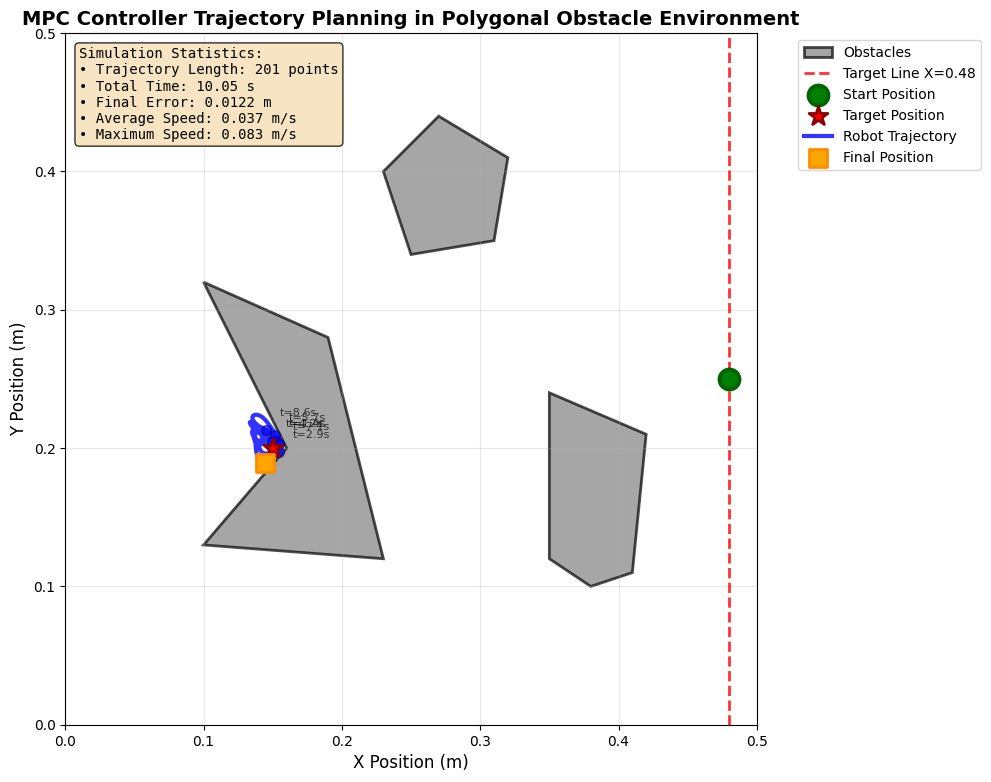

📊 Trajectory visualization completed!


In [60]:
# =============================================================================
# 可视化机器人轨迹和环境 (英文版)
# =============================================================================

# 首先检查并转换数据格式
print("Checking simulation data...")
print(f"q_sim type: {type(q_sim)}")
print(f"dq_sim type: {type(dq_sim)}")

# 转换为numpy数组
if isinstance(q_sim, list):
    q_sim = np.array(q_sim)
    print("✅ q_sim converted to numpy array")

if isinstance(dq_sim, list):  
    dq_sim = np.array(dq_sim)
    print("✅ dq_sim converted to numpy array")

print(f"Trajectory data shape: q_sim {q_sim.shape}, dq_sim {dq_sim.shape}")

if len(q_sim) == 0:
    print("❌ No trajectory data to visualize, please run simulation first")
else:
    print(f"Starting visualization of {len(q_sim)} trajectory points...")
    
    plt.figure(figsize=(10, 10))

    # 设置坐标轴范围
    plt.xlim([q_min[0], q_max[0]])
    plt.ylim([q_min[1], q_max[1]])
    plt.gca().set_aspect('equal')

    # 绘制障碍物
    for i, poly in enumerate(collision_env.poly_list):
        polygon_patch = patches.Polygon(poly, facecolor='gray', alpha=0.7, 
                                      edgecolor='black', linewidth=2, 
                                      label='Obstacles' if i == 0 else "")
        plt.gca().add_patch(polygon_patch)

    # 绘制目标线（X = xd）
    plt.axvline(x=xd, color='red', linestyle='--', alpha=0.8, linewidth=2, label=f'Target Line X={xd}')

    # 绘制起始位置
    plt.scatter(q0[0], q0[1], c='green', s=200, marker='o', 
               edgecolors='darkgreen', linewidth=3, label='Start Position', zorder=10)

    # 绘制目标位置
    plt.scatter(qg[0], qg[1], c='red', s=200, marker='*', 
               edgecolors='darkred', linewidth=2, label='Target Position', zorder=10)

    # 绘制机器人轨迹
    plt.plot(q_sim[:, 0], q_sim[:, 1], 'b-', linewidth=3, alpha=0.8, label='Robot Trajectory')

    # 在轨迹上标记一些点显示时间进展
    step_markers = np.linspace(0, len(q_sim)-1, 8, dtype=int)
    for i, idx in enumerate(step_markers[1:-1]):  # 跳过起点和终点
        plt.scatter(q_sim[idx, 0], q_sim[idx, 1], c='blue', s=50, alpha=0.6, 
                   edgecolors='darkblue', zorder=8)
        plt.text(q_sim[idx, 0]+0.01, q_sim[idx, 1]+0.01, f't={idx*dt_control:.1f}s', 
                fontsize=8, alpha=0.7)

    # 绘制最终位置
    plt.scatter(q_sim[-1, 0], q_sim[-1, 1], c='orange', s=150, marker='s', 
               edgecolors='darkorange', linewidth=2, label='Final Position', zorder=10)

    # 设置图例和标签
    plt.xlabel('X Position (m)', fontsize=12)
    plt.ylabel('Y Position (m)', fontsize=12)
    plt.title('MPC Controller Trajectory Planning in Polygonal Obstacle Environment', fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # 添加统计信息文本框
    info_text = f"""Simulation Statistics:
• Trajectory Length: {len(q_sim)} points
• Total Time: {len(q_sim)*dt_control:.2f} s  
• Final Error: {np.linalg.norm(q_sim[-1] - qg):.4f} m
• Average Speed: {np.mean(np.linalg.norm(dq_sim, axis=1)):.3f} m/s
• Maximum Speed: {np.max(np.linalg.norm(dq_sim, axis=1)):.3f} m/s"""

    plt.text(0.02, 0.98, info_text, transform=plt.gca().transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=10, fontfamily='monospace')

    plt.show()

    print("📊 Trajectory visualization completed!")

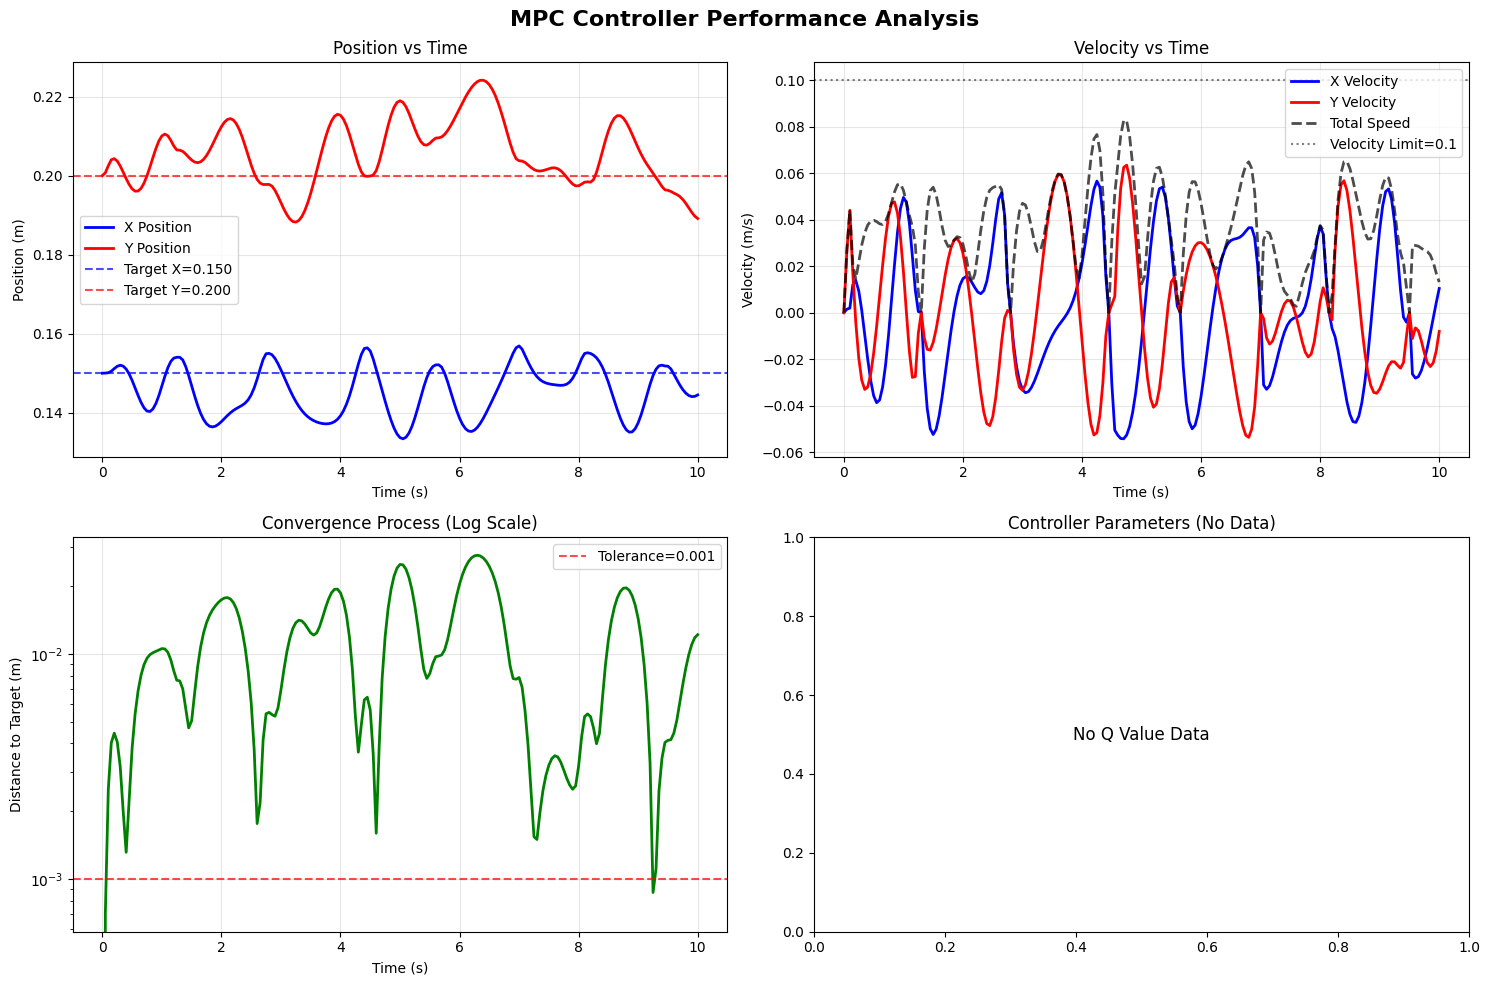


📈 Performance Statistics:
• Average Speed: 0.0367 m/s
• Maximum Speed: 0.0828 m/s
• Speed Standard Deviation: 0.0183 m/s
• Total Trajectory Length: 0.3672 m
• Final Distance to Target: 0.0122 m


In [61]:
# =============================================================================
# 性能分析图表 (英文版)
# =============================================================================

# 创建时间轴
time_axis = np.arange(len(q_sim)) * dt_control

# 创建子图
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('MPC Controller Performance Analysis', fontsize=16, fontweight='bold')

# 1. 位置轨迹
axes[0, 0].plot(time_axis, q_sim[:, 0], 'b-', label='X Position', linewidth=2)
axes[0, 0].plot(time_axis, q_sim[:, 1], 'r-', label='Y Position', linewidth=2)
axes[0, 0].axhline(y=qg[0], color='b', linestyle='--', alpha=0.7, label=f'Target X={qg[0]:.3f}')
axes[0, 0].axhline(y=qg[1], color='r', linestyle='--', alpha=0.7, label=f'Target Y={qg[1]:.3f}')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Position (m)')
axes[0, 0].set_title('Position vs Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 速度轨迹
speed = np.linalg.norm(dq_sim, axis=1)
axes[0, 1].plot(time_axis, dq_sim[:, 0], 'b-', label='X Velocity', linewidth=2)
axes[0, 1].plot(time_axis, dq_sim[:, 1], 'r-', label='Y Velocity', linewidth=2)
axes[0, 1].plot(time_axis, speed, 'k--', label='Total Speed', linewidth=2, alpha=0.7)
axes[0, 1].axhline(y=vel_lim, color='k', linestyle=':', alpha=0.5, label=f'Velocity Limit={vel_lim}')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Velocity (m/s)')
axes[0, 1].set_title('Velocity vs Time')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 到目标的距离
dist_to_goal = np.linalg.norm(q_sim - qg, axis=1)
axes[1, 0].semilogy(time_axis, dist_to_goal, 'g-', linewidth=2)
axes[1, 0].axhline(y=tolerance, color='r', linestyle='--', alpha=0.7, 
                   label=f'Tolerance={tolerance}')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Distance to Target (m)')
axes[1, 0].set_title('Convergence Process (Log Scale)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Q值和碰撞统计
if len(mpc_controller.Q_log) > 0:
    time_q = np.arange(len(mpc_controller.Q_log)) * dt_control
    axes[1, 1].semilogy(time_q, mpc_controller.Q_log, 'purple', linewidth=2, label='Q Value')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Q Value (Log Scale)')
    axes[1, 1].set_title('Controller Q Value Changes')
    
    # 添加碰撞统计作为第二个Y轴
    ax2 = axes[1, 1].twinx()
    if len(mpc_controller.collision_log) > 0:
        ax2.bar(time_q, mpc_controller.collision_log, alpha=0.3, color='red', width=dt_control*0.8, label='Collision Candidates')
        ax2.set_ylabel('Number of Collision Candidates', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
    
    axes[1, 1].legend(loc='upper left')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No Q Value Data', ha='center', va='center', 
                   transform=axes[1, 1].transAxes, fontsize=12)
    axes[1, 1].set_title('Controller Parameters (No Data)')

plt.tight_layout()
plt.show()

# 打印统计信息
print("\n📈 Performance Statistics:")
print(f"• Average Speed: {np.mean(speed):.4f} m/s")
print(f"• Maximum Speed: {np.max(speed):.4f} m/s") 
print(f"• Speed Standard Deviation: {np.std(speed):.4f} m/s")
print(f"• Total Trajectory Length: {np.sum(np.linalg.norm(np.diff(q_sim, axis=0), axis=1)):.4f} m")
print(f"• Final Distance to Target: {dist_to_goal[-1]:.4f} m")
if len(mpc_controller.collision_log) > 0:
    print(f"• Average Collision Candidates: {np.mean(mpc_controller.collision_log):.1f}")
    print(f"• Maximum Collision Candidates: {np.max(mpc_controller.collision_log)}")

### 动画可视化

In [62]:
print("\n🎬 Animation Description:")
print("• Blue circle: Robot current position") 
print("• Blue solid line: Robot historical trajectory")
print("• Purple dashed line: MPC predicted trajectory")
print("• Green thin lines: Candidate trajectories (brighter = better)")
print("• Gray polygons: Static obstacles")
print("• Red star: Target position")
print("• Red dashed line: Target line")


🎬 Animation Description:
• Blue circle: Robot current position
• Blue solid line: Robot historical trajectory
• Purple dashed line: MPC predicted trajectory
• Green thin lines: Candidate trajectories (brighter = better)
• Gray polygons: Static obstacles
• Red star: Target position
• Red dashed line: Target line
